In [117]:
import os
os.environ["CRDS_PATH"] = os.path.expanduser("~/crds_cache")
os.makedirs(os.environ["CRDS_PATH"], exist_ok=True)

os.environ["CRDS_SERVER_URL"] = "https://jwst-crds.stsci.edu"
os.environ["CRDS_CONTEXT"] = "jwst_1460.pmap"

from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astroquery.svo_fps import SvoFps
from astropy.wcs import WCS
from astropy.io import fits
from dust_extinction.averages import RL85_MWGC
from dust_extinction.parameter_averages import CCM89

def get_mag(catalog, ww, filtername='f140m' ):
    print(ww.proj_plane_pixel_area())
    
    flux= (catalog['flux_fit_' + filtername] * u.MJy/u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
    eflux_jy = (catalog['flux_err_' + filtername] * u.MJy/u.sr *  ww.proj_plane_pixel_area()).to(u.Jy)

    jfilts = SvoFps.get_filter_list('JWST')
    jfilts.add_index('filterID')
    wav = int(filtername[1:-1])

    zeropoint_ab = 3631 * u.Jy  # Default to AB magnitude zero point
 
    if wav < 500:

        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/NIRCam.{filtername.upper()}']['ZeroPoint'], u.Jy)
    else:
        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/MIRI.{filtername.upper()}']['ZeroPoint'], u.Jy)
   
    abmag = -2.5 * np.log10(flux / zeropoint_ab) * u.mag
    abmag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    vegamag = -2.5 * np.log10(flux / zeropoint_vega) * u.mag
    vegamag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    return  vegamag, vegamag_err, abmag, abmag_err



catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new.fits')
nmatch = catalog['nmatch_bands']
catalog = catalog[nmatch>3]
image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f150w": "/orange/adamginsburg/jwst/w51/F150W/pipeline/jw06151-o001_t001_nircam_clear-f150w-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}

f140m_header = fits.getheader(image_filenames['f140m'], ext=('SCI', 1))
f162m_header = fits.getheader(image_filenames['f162m'], ext=('SCI', 1))
f182m_header = fits.getheader(image_filenames['f182m'], ext=('SCI', 1))
f210m_header = fits.getheader(image_filenames['f210m'], ext=('SCI', 1))
f335m_header = fits.getheader(image_filenames['f335m'], ext=('SCI', 1))
f360m_header = fits.getheader(image_filenames['f360m'], ext=('SCI', 1))
f405n_header = fits.getheader(image_filenames['f405n'], ext=('SCI', 1))
f410m_header = fits.getheader(image_filenames['f410m'], ext=('SCI', 1))
f480m_header = fits.getheader(image_filenames['f480m'], ext=('SCI', 1))
f560w_header = fits.getheader(image_filenames['f560w'], ext=('SCI', 1))
f770w_header = fits.getheader(image_filenames['f770w'], ext=('SCI', 1))
f1000w_header = fits.getheader(image_filenames['f1000w'], ext=('SCI', 1))
f1280w_header = fits.getheader(image_filenames['f1280w'], ext=('SCI', 1))
f2100w_header = fits.getheader(image_filenames['f2100w'], ext=('SCI', 1))



f140m_mag = get_mag(catalog, WCS(f140m_header), filtername='f140m')
f162m_mag = get_mag(catalog, WCS(f162m_header), filtername='f162m')
f182m_mag = get_mag(catalog, WCS(f182m_header), filtername='f182m')
f210m_mag = get_mag(catalog, WCS(f210m_header), filtername='f210m')
f335m_mag = get_mag(catalog, WCS(f335m_header), filtername='f335m')
f360m_mag = get_mag(catalog, WCS(f360m_header), filtername='f360m')
f405n_mag = get_mag(catalog, WCS(f405n_header), filtername='f405n')
f410m_mag = get_mag(catalog, WCS(f410m_header), filtername='f410m')
f480m_mag = get_mag(catalog, WCS(f480m_header), filtername='f480m')
f560w_mag = get_mag(catalog, WCS(f560w_header), filtername='f560w')
f770w_mag = get_mag(catalog, WCS(f770w_header), filtername='f770w')
f1000w_mag = get_mag(catalog, WCS(f1000w_header), filtername='f1000w')
f1280w_mag = get_mag(catalog, WCS(f1280w_header), filtername='f1280w')
f2100w_mag = get_mag(catalog, WCS(f2100w_header), filtername='f2100w')

f187n_header = fits.getheader(image_filenames['f187n'], ext=('SCI', 1))
f187n_mag = get_mag(catalog, WCS(f187n_header), filtername='f187n')


from dust_extinction.averages import RL85_MWGC
from dust_extinction.parameter_averages import CCM89

ext = RL85_MWGC()
def plot_extvec_cmd(ax, color1, mag1, ext=RL85_MWGC(), extvec_scale=200, start=None,
                    color='y', head_width=0.5, color1_data=None, mag1_data=None):
    def get_wave(c):
        if c == '410m405': return 4.10*u.um
        if c == '405m410': return 4.05*u.um
        if c == 'Hmag': return 1.634*u.um
        if c == 'Ksmag': return 2.143527*u.um
        return int(c[1:-1])/100*u.um

    w1 = get_wave(color1[0])
    w2 = get_wave(color1[1])
    w3 = get_wave(mag1[0])

    if w1 > w2:
        w1, w2 = w2, w1
        color1 = color1[::-1]
    print(w1,w2,w3)

    # Only plot if all are in valid range
    try:
        e_1 = ext(1/w1) * extvec_scale
        e_2 = ext(1/w2) * extvec_scale
        e_3 = ext(1/w3) * extvec_scale
    except ValueError as e:
        print(f"Extinction vector not plotted: {e}")
        return
    print(w1,w2,w3)
    print(e_1, e_2, e_3)
    if start == None:
        mean_color1 = np.nanmean(color1_data)
        mean_mag1 = np.nanmean(mag1_data)
        std_color1 = np.nanstd(color1_data)
        std_mag1 = np.nanstd(mag1_data)
        if e_1 - e_2 < 0:
            std_color1 *= -1
        
    
        start2 = (mean_color1 + 2*std_color1, mean_mag1 + 2*std_mag1)
    else:
        start2 = start
    
    # Strip units for plotting if present
    if hasattr(start2[0], 'value'):
        start2_x = start2[0].value
        start2_y = start2[1].value
    else:
        start2_x = start2[0]
        start2_y = start2[1]

    ax.annotate(f'$A_V={extvec_scale}$', xy=(start2_x + (e_1 - e_2), start2_y + e_3),
                xytext=(start2_x, start2_y),
                arrowprops=dict(arrowstyle='-|>', color=color,
                                shrinkA=0, shrinkB=0,
                                mutation_scale=20, linewidth=1.5))
    ax.plot([], [], color=color, marker='>', markersize=8,
            label=f'$A_V={extvec_scale}$', linestyle='-', linewidth=2)


imgsavedir = '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/plots/cmds/'
filters = {
    'f140m': f140m_mag,
    'f162m': f162m_mag,
    'f182m': f182m_mag,
    'f187n': f187n_mag,
    'f210m': f210m_mag,
    'f335m': f335m_mag,
    'f360m': f360m_mag,
    'f405n': f405n_mag,
    'f410m': f410m_mag,
    'f480m': f480m_mag,
    'f560w': f560w_mag,
    'f770w': f770w_mag,
    'f1000w': f1000w_mag,
    'f1280w': f1280w_mag,
    'f2100w': f2100w_mag,
}
filter_names = list(filters.keys())

def get_line_excess(catalog, narrow, wide):
    ww_narrow = WCS(fits.getheader(image_filenames[narrow], ext=('SCI', 1)))
    ww_wide = WCS(fits.getheader(image_filenames[wide], ext=('SCI', 1)))
    data_narrow = (catalog['flux_fit_' + narrow] * u.MJy/u.sr * ww_narrow.proj_plane_pixel_area()).to(u.Jy)
    data_wide = (catalog['flux_fit_' + wide] * u.MJy/u.sr * ww_wide.proj_plane_pixel_area()).to(u.Jy)

    wavelength_table_narrow = SvoFps.get_transmission_data(f'JWST/NIRCAM.{narrow}')
    wavelength_table_wide = SvoFps.get_transmission_data(f'JWST/NIRCAM.{wide}')

    waves_wide = wavelength_table_wide['Wavelength']
    trans_narrow = np.interp(waves_wide, wavelength_table_narrow['Wavelength'], wavelength_table_narrow['Transmission'])
    trans_wide = wavelength_table_wide['Transmission']


    fractional_bandwidth = ( (trans_wide/trans_wide.max()) * (trans_narrow/trans_narrow.max()) ).sum() / (trans_wide/trans_wide.max()).sum()
    print(f'Fractional bandwidth: {fractional_bandwidth}')
    if fractional_bandwidth == 1:
        print("The filters either have no overlap or are identical. Exiting")
        return


    wide_minus_narrow = (data_wide - data_narrow * fractional_bandwidth) / (1-fractional_bandwidth)
    #return wide_minus_narrow

    narrow_minus_wide = data_narrow - wide_minus_narrow
    #narrow_minus_wide = (data_narrow - data_wide * fractional_bandwidth) / (1-fractional_bandwidth)
    return np.array(narrow_minus_wide)  # Ensure writable copy

paa_excess = get_line_excess(catalog, 'f187n', 'f182m')
bra_excess = get_line_excess(catalog, 'f405n', 'f410m')

print('paa_excess', paa_excess)



'datfix' made the change 'Set DATE-BEG to '2025-05-06T16:37:42.537' from MJD-BEG.
Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'.
'obsfix' made the change 'Set OBSGEO-L to  -106.570116 from OBSGEO-[XYZ].
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'.
invalid value encountered in log10
'datfix' made the change 'Set DATE-BEG to '2025-05-06T13:57:33.059' from MJD-BEG.
Set DATE-AVG to '2025-05-06T14:19:06.870' from MJD-AVG.
Set DATE-END to '2025-05-06T14:41:02.194' from MJD-END'.
'obsfix' made the change 'Set OBSGEO-L to  -106.647326 from OBSGEO-[XYZ].
Set OBSGEO-B to   -25.220336 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610512569.543 from OBSGEO-[XYZ]'.
invalid value encountered in log10
'datfix' made the change 'Set DATE-BEG to '2025-05-06T14:49:48.239' from MJD-BEG.
Set DATE-AVG to '2025-05-06T15:11:59.611' from MJD-AVG.
Set DATE-END to '2025-05-06T15:35:36.878' from MJD-END'.

7.525093724479512e-11 deg2
7.52790883669383e-11 deg2
7.52510476872822e-11 deg2
7.52514718037244e-11 deg2
3.053877779107583e-10 deg2
3.0536898714608487e-10 deg2
3.056563930691893e-10 deg2
3.0541063885182936e-10 deg2
3.054668262896466e-10 deg2
9.491459138193236e-10 deg2
9.49145905084584e-10 deg2


invalid value encountered in log10
'datfix' made the change 'Set DATE-BEG to '2024-09-08T10:27:14.788' from MJD-BEG.
Set DATE-AVG to '2024-09-08T11:39:49.277' from MJD-AVG.
Set DATE-END to '2024-09-08T12:52:42.510' from MJD-END'.
'obsfix' made the change 'Set OBSGEO-L to   -34.680379 from OBSGEO-[XYZ].
Set OBSGEO-B to    -3.797166 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291845460.779 from OBSGEO-[XYZ]'.
invalid value encountered in log10
'datfix' made the change 'Set DATE-BEG to '2024-09-08T10:35:06.531' from MJD-BEG.
Set DATE-AVG to '2024-09-08T11:47:44.336' from MJD-AVG.
Set DATE-END to '2024-09-08T13:00:37.070' from MJD-END'.
'obsfix' made the change 'Set OBSGEO-L to   -34.671387 from OBSGEO-[XYZ].
Set OBSGEO-B to    -3.791203 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291801554.144 from OBSGEO-[XYZ]'.
invalid value encountered in log10
'datfix' made the change 'Set DATE-BEG to '2024-09-08T10:43:09.411' from MJD-BEG.
Set DATE-AVG to '2024-09-08T11:55:48.768' from MJD-AVG.
Set DATE-END to '2024

9.491458943030916e-10 deg2
9.49145885655769e-10 deg2
9.491458757317268e-10 deg2
7.524574264515582e-11 deg2
Fractional bandwidth: 0.09655212419159323
Fractional bandwidth: 0.1027882360899125
paa_excess [          nan 2.7762679e-09           nan ...           nan           nan
           nan]


'datfix' made the change 'Set DATE-BEG to '2025-05-06T13:02:15.381' from MJD-BEG.
Set DATE-AVG to '2025-05-06T13:24:26.757' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.021' from MJD-END'.
'obsfix' made the change 'Set OBSGEO-L to  -106.673970 from OBSGEO-[XYZ].
Set OBSGEO-B to   -25.202550 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191894.941 from OBSGEO-[XYZ]'.
'datfix' made the change 'Set DATE-BEG to '2025-05-06T15:43:50.732' from MJD-BEG.
Set DATE-AVG to '2025-05-06T16:06:02.828' from MJD-AVG.
Set DATE-END to '2025-05-06T16:29:39.435' from MJD-END'.
'obsfix' made the change 'Set OBSGEO-L to  -106.596047 from OBSGEO-[XYZ].
Set OBSGEO-B to   -25.254571 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611129611.449 from OBSGEO-[XYZ]'.


In [118]:
from astropy import units as u
from astropy import constants
from sensitivity import cardelli_law
from pyspeckit.spectrum.models import hydrogen
from hii_sensitivity import ha_to_hb_1e4, paa_to_hb_1e4, bra_to_hgamma_1e4, pab_to_hgamma_1e4, hg_to_hb_1e4, wl_paa
from astroquery.svo_fps import SvoFps

wl_bra = hydrogen.wavelength['bracketta']*u.um
twomass = SvoFps.get_filter_list('2MASS')
wl_Ks = twomass[twomass['filterID'].astype(str)=='2MASS/2MASS.Ks']['WavelengthCen'][0] * u.AA
def lacc(mdot, rstar=u.R_sun, mstar=u.M_sun):
    # Alcala+ 2017 eqn 1
    # 1.25 comes from assuming r_inner disk = 5 r_star
    return (mdot / 1.25 * constants.G * mstar / rstar).to(u.L_sun)
def log_pab(lacc):
    # from table B1 of Alcala+2017:
    # log L_acc = 1.06 log L_pab + 2.76
    # so
    # log L_pab = (log L_acc - 2.76) / 1.06
    return 1/1.06 * np.log10(lacc/u.L_sun) - 2.76/1.06

def log_paa(lacc):
    # pab * (paa / hb) * (hb / hg) *  (hg / pab)
    return log_pab(lacc) + np.log10(paa_to_hb_1e4 / hg_to_hb_1e4 / pab_to_hgamma_1e4)

def log_bra(lacc):
    # brackett alpha prediction from PaB (could use BrG too...)
    return log_pab(lacc) + np.log10(bra_to_hgamma_1e4 / pab_to_hgamma_1e4)

def L_paa(lacc):
    return 10**log_paa(lacc) * u.L_sun

def L_bra(lacc):
    return 10**log_bra(lacc) * u.L_sun

def S_paa(lacc, distance=5.4*u.kpc, A_K=0):
    A_paa = (cardelli_law(wl_paa) / cardelli_law(wl_Ks)) * A_K
    attenuation = 10**(-A_paa / 2.5)
    return (L_paa(lacc) / (4*np.pi*distance**2)).to(u.erg/u.s/u.cm**2) * attenuation

def S_bra(lacc, distance=5.4*u.kpc, A_K=0):
    A_bra = (cardelli_law(wl_bra) / cardelli_law(wl_Ks)) * A_K
    attenuation = 10**(-A_bra / 2.5)
    return (L_bra(lacc) / (4*np.pi*distance**2)).to(u.erg/u.s/u.cm**2) * attenuation

#lacc_vals = lacc(mdot)
#spaa = S_paa(lacc_vals, distance=5.4*u.kpc)
#sbra = S_bra(lacc_vals, distance=5.4*u.kpc)

#get the inverse
def macc(Ldot, rstar=u.R_sun, mstar=u.M_sun):
    # Invert the lacc equation to get macc
    return (Ldot * 1.25 * rstar / (constants.G * mstar)).to(u.M_sun/u.yr)
def Lbra_to_lacc(L_bra):
    loglacc = 1.06*(np.log10(L_bra/u.L_sun) +2.76/1.06 - np.log10(paa_to_hb_1e4 / hg_to_hb_1e4 / pab_to_hgamma_1e4))
    return 10**loglacc * u.L_sun
def Lpaa_to_lacc(L_paa):
    loglacc = 1.06*(np.log10(L_paa/u.L_sun) +2.76/1.06 - np.log10(bra_to_hgamma_1e4 / pab_to_hgamma_1e4))
    return 10**loglacc * u.L_sun

def S_paa_to_lacc(S_paa, distance=5.4*u.kpc, A_K=0):
    # Invert the S_paa equation to get lacc
    A_paa = (cardelli_law(wl_paa) / cardelli_law(wl_Ks)) * A_K
    attenuation = 10**(-A_paa / 2.5)
    L_paa = (S_paa * 4*np.pi*distance**2 / attenuation).to(u.L_sun)
    L_acc = Lbra_to_lacc(L_paa)
    return L_acc


def S_bra_to_lacc(S_bra, distance=5.4*u.kpc, A_K=0):
    # Invert the S_bra equation to get lacc
    A_bra = (cardelli_law(wl_bra) / cardelli_law(wl_Ks)) * A_K
    attenuation = 10**(-A_bra / 2.5)
    L_bra = (S_bra * 4*np.pi*distance**2 / attenuation).to(u.L_sun)
    L_acc = Lbra_to_lacc(L_bra)
    return L_acc

 col1    col2    col3       col4          col5       col6   col7   col8   col9 col10 col11 col12  col13 col14 col15 col16 col17 col18   col19   col20  col21   col22    col23     col24     col25   col26   col27   col28  col29  col30  col31  col32  col33  col34  col35  col36  col37  col38  col39  col40  col41  col42  col43  col44  col45  col46  col47  col48  col49  col50 
------ ------- ------- -------------- ------------ ------- ------ ------ ----- ----- ----- ------ ----- ----- ----- ----- ----- ----- --------- ----- -------- ------ --------- --------- --------- ------ ------- ------- ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------
0.0207 0.15867     6.0   0.0908484459 1.0897678296   0.091  -1.33 3.4326 3.409     0   0.0  0.545   0.0   0.0   0.0   0.0   0.0    -1 -3.89e-14   0.0   0.6936 0.2855  0.003749  0.001011  0.009172   -1.0 0.02085   8.095  9.712  7.478  6.249  5.749  5.324 

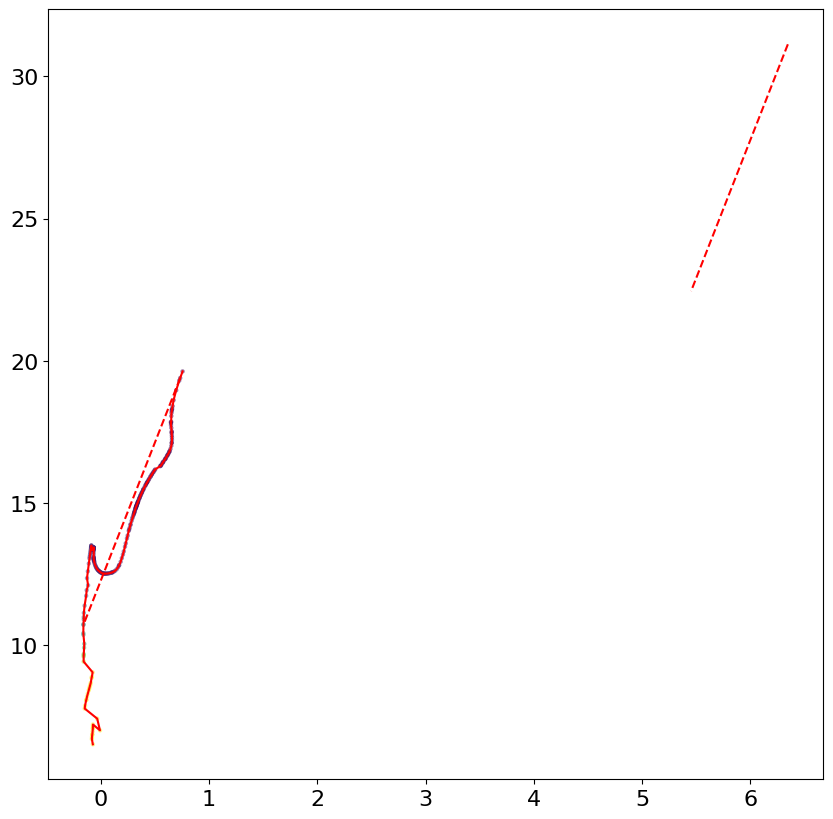

In [119]:
from astropy.table import Table
import crds
parsec_av0 = Table.read('/home/t.yoo/parsec_av0.txt', format='ascii')
parsec_av0.pprint(max_width=-1, max_lines=-1)   
m_init = parsec_av0['col4']  
parsec_av0 = parsec_av0[m_init<300]              
logage_av0 = parsec_av0['col3']
mass_av0 = parsec_av0['col6']
print(np.min(m_init), np.max(m_init))
print(np.min(mass_av0), np.max(mass_av0))
F140Mmag_av0 = parsec_av0['col39'] + 5*np.log10(5400)-5
F162Mmag_av0 = parsec_av0['col40']+ 5*np.log10(5400)-5
F182Mmag_av0 = parsec_av0['col41']+ 5*np.log10(5400)-5
F210Mmag_av0 = parsec_av0['col42']+ 5*np.log10(5400)-5
F335Mmag_av0 = parsec_av0['col45']+ 5*np.log10(5400)-5
F360Mmag_av0 = parsec_av0['col46']+ 5*np.log10(5400)-5
F410Mmag_av0 = parsec_av0['col47']+ 5*np.log10(5400)-5
F480Mmag_av0 = parsec_av0['col50']+ 5*np.log10(5400)-5
parsec_av10 = Table.read('/home/t.yoo/parsec_av10.txt', format='ascii')
logage_av10 = parsec_av10['col3']
mass_av10 = parsec_av10['col6']
F140Mmag_av10 = parsec_av10['col39']+ 5*np.log10(5400)-5
F162Mmag_av10 = parsec_av10['col40']+ 5*np.log10(5400)-5
F182Mmag_av10 = parsec_av10['col41']+ 5*np.log10(5400)-5
F210Mmag_av10 = parsec_av10['col42']+ 5*np.log10(5400)-5
F335Mmag_av10 = parsec_av10['col45']+ 5*np.log10(5400)-5
F360Mmag_av10 = parsec_av10['col46']+ 5*np.log10(5400)-5
F410Mmag_av10 = parsec_av10['col47']+ 5*np.log10(5400)-5
F480Mmag_av10 = parsec_av10['col50']+ 5*np.log10(5400)-5

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
age_idx = logage_av0 == 6
color = F140Mmag_av0[age_idx] - F210Mmag_av0[age_idx]
magnitude = F140Mmag_av0[age_idx]
color_for_points = mass_av0[age_idx]
cmap = plt.get_cmap('viridis')

ax.plot(F140Mmag_av0[age_idx] - F210Mmag_av0[age_idx], F140Mmag_av0[age_idx], color='r', label='PARSEC isochrones (A_V=0)')
# also draw a single line connecting the first and the last point of the isochrone
idx_01msun = np.argmin(np.abs(mass_av0[age_idx]-0.1))
idx_20msun = np.argmin(np.abs(mass_av0[age_idx]-20))
ax.scatter(color.value, magnitude.value, s=10, c=color_for_points, cmap=cmap, alpha=0.5, edgecolor='none',vmin=np.nanpercentile(color_for_points, 10), vmax=np.nanpercentile(color_for_points, 90))
isochrone_x_start = F140Mmag_av0[age_idx][idx_01msun] - F210Mmag_av0[age_idx][idx_01msun]
isochrone_x_end = F140Mmag_av0[age_idx][idx_20msun] - F210Mmag_av0[age_idx][idx_20msun]
isocrhone_y_start = F140Mmag_av0[age_idx][idx_01msun]
isocrhone_y_end = F140Mmag_av0[age_idx][idx_20msun]

A_K_scale = 5
A_V_scale = A_K_scale * 10
ax.plot([isochrone_x_start, isochrone_x_end], [isocrhone_y_start, isocrhone_y_end], color='r', linestyle='--')
ax.plot([isochrone_x_start+(ext(1/1.4/u.um)-ext(1/2.10/u.um))*A_V_scale, isochrone_x_end+(ext(1/1.4/u.um)-ext(1/2.10/u.um))*A_V_scale], 
[isocrhone_y_start+(ext(1/1.4/u.um))*A_V_scale, isocrhone_y_end+(ext(1/1.4/u.um))*A_V_scale], color='r', linestyle='--')
# extrapolate the linear part of the isochrone to the left and right by 0.5 mag in color
color_slope = (isocrhone_y_end - isocrhone_y_start) / (isochrone_x_end - isochrone_x_start)
color_intercept = isocrhone_y_start - color_slope * isochrone_x_start

w_color1_1: 1.4 um w_color1_2: 2.1 um w_mag1: 1.4 um
[           nan 8.95746255e-06            nan ...            nan
            nan            nan] solLum


invalid value encountered in log10


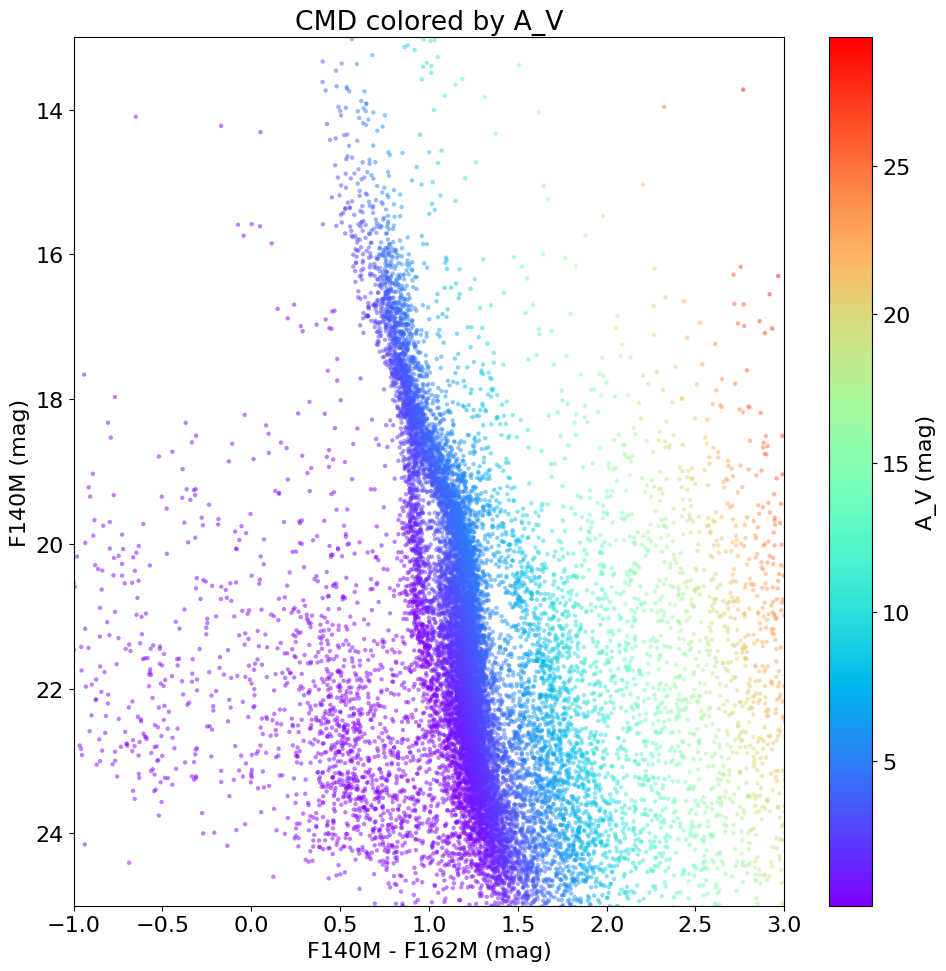

In [120]:
# get A_V for each source by measuring the distance to the isochrone fiducial line along the extinction vector
# if source lies on the negative side of the isochrone, assign A_V=0
def get_av(color, mag, ext=RL85_MWGC(), color1=('f140m', 'f162m'), mag1=('f140m',), isochrone_line_params=(color_slope, color_intercept)):
    # Get the slope and intercept of the isochrone line
    m_iso, b_iso = isochrone_line_params

    # Get the extinction vector components
    w_color1_1 = int(color1[0][1:-1])/100*u.um
    w_color1_2 = int(color1[1][1:-1])/100*u.um
    w_mag1 = int(mag1[0][1:-1])/100*u.um
    print('w_color1_1:', w_color1_1, 'w_color1_2:', w_color1_2, 'w_mag1:', w_mag1)

    e_color1_1 = ext(1/w_color1_1)
    e_color1_2 = ext(1/w_color1_2)
    e_mag1 = ext(1/w_mag1)

    # get the contact to the isochrone line along the extinction vector
    # the extinction vector can be represented as a line with slope m_ext = e_mag1 / (e_color1_1 - e_color1_2) and passing through the point (color, mag)
    m_ext = e_mag1 / (e_color1_1 - e_color1_2)
    b_ext = mag - m_ext * color

    # find the intersection of the isochrone line and the extinction vector
    x_int = (b_ext - b_iso) / (m_iso - m_ext)
    y_int = m_iso * x_int + b_iso

    # calculate A_V as the distance from (color, mag) to (x_int, y_int) along the extinction vector
    av = (mag - y_int) / ext(1/w_mag1)
    av[av < 0] = 0
    return av
def get_mass(color, mag, isochrone_color, isochrone_mag, mass_iso, ext=RL85_MWGC(), color1=('f140m', 'f162m'), mag1=('f140m',), isochrone_line_params=(color_slope, color_intercept)):
    # make a straight line along dust extinction vector and find the intersection with the isochrone, then assign mass based on the isochrone mass at that point
    # the extinction vector can be represented as a line with slope m_ext = e_mag1 / (e_color1_1 - e_color1_2) and passing through the point (color, mag)
    w_color1_1 = int(color1[0][1:-1])/100*u.um
    w_color1_2 = int(color1[1][1:-1])/100*u.um
    w_mag1 = int(mag1[0][1:-1])/100*u.um
    e_color1_1 = ext(1/w_color1_1)
    e_color1_2 = ext(1/w_color1_2)
    e_mag1 = ext(1/w_mag1)
    m_ext = e_mag1 / (e_color1_1 - e_color1_2)
    b_ext = mag - m_ext * color 
    # find the intersection with the isochrone, which can be represented as a line with slope m_iso and intercept b_iso
    m_iso, b_iso = color_slope, color_intercept
    x_int = (b_ext - b_iso) / (m_iso - m_ext)
    y_int = m_iso * x_int + b_iso
    # find the closest point on the isochrone to (x_int, y_int). x_init and y_init are arrays
    massarr = []
    for x, y in zip(x_int, y_int):
        dist = np.sqrt((isochrone_color - x)**2 + (isochrone_mag - y)**2)
        idx_closest = np.argmin(dist)
        massarr.append(mass_iso[idx_closest])
    return np.array(massarr)
color = filters['f140m'][0] - filters['f210m'][0]
magnitude = filters['f140m'][0]
av_values = get_av(color.value, magnitude.value, ext=ext, color1=('f140m', 'f210m'), mag1=('f140m',), isochrone_line_params=(color_slope, color_intercept))
#mass_values = get_mass(color.value, magnitude.value, isochrone_color=F140Mmag_av0 - F210Mmag_av0, isochrone_mag=F140Mmag_av0, mass_iso=mass_av0)

#dust extinction correction for recombination line excess
paa_excess_int = paa_excess * 10**(cardelli_law(wl_paa) * av_values / 2.5) / 10**(0.0258 * av_values)
bra_excess_int = bra_excess * 10**(cardelli_law(wl_bra) * av_values / 2.5) / 10**(-0.0136 * av_values)

paa_excess_ergscm2 = paa_excess_int * 1e-23 * (3e18 / wl_paa.to(u.AA).value**2) * u.erg/u.s/u.cm**2 *236.69 #bandwidth of F187N filter in Angstrom
bra_excess_ergscm2 = bra_excess_int  * 1e-23 * (3e18 / wl_bra.to(u.AA).value**2) * u.erg/u.s/u.cm**2 * 454.87 #bandwidth of F405N
L_paa_values = S_paa_to_lacc(paa_excess_ergscm2, distance=5.4*u.kpc, A_K=0.1*av_values)
L_bra_values = S_bra_to_lacc(bra_excess_ergscm2, distance=5.4*u.kpc, A_K=0.1*av_values)
print(L_paa_values)
macc_from_paa = macc(L_paa_values)
macc_from_bra = macc(L_bra_values)


# plot the same CMD but color code by A_V




fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
cmap = plt.get_cmap('rainbow')
ax.scatter(color.value, magnitude.value, s=10, c=av_values, cmap=cmap, alpha=0.5, edgecolor='none', vmin=np.nanpercentile(av_values, 10), vmax=np.nanpercentile(av_values, 90))
ax.set_xlabel('F140M - F162M (mag)')
ax.set_ylabel('F140M (mag)')
ax.set_title('CMD colored by A_V')  
ax.set_xlim(-1,3)
ax.set_ylim(25, 13)
# add colorbar for A_V
norm = plt.Normalize(vmin=np.nanpercentile(av_values, 10), vmax=np.nanpercentile(av_values, 90))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('A_V (mag)')
plt.tight_layout()

In [135]:
from astropy.table import Table
from astroquery.svo_fps import SvoFps
from scipy.integrate import simpson, trapezoid
color = (filters['f140m'][0] - filters['f210m'][0])


def check_roman_sensivity(catalog, idx, filters = ['f140m', 'f162m', 'f182m', 'f187n', 'f210m', 'f335m', 'f360m', 'f405n', 'f410m', 'f480m', 'f560w', 'f770w', 'f1000w', 'f1280w', 'f2100w'],
roman_limits = [24.4, 24.1, 24.1, 24.0, 23.9, 23.3, 23.0], sat_limits = [14.6, 14.2, 14.2, 14.0, 13.9, 13.2, 13.1 ],
):
    
    
    #extrapolate the flux_yso to 0.4micron
    

    finite_filters = [f for f in filters if np.isfinite(catalog['flux_fit_'+f][idx])]
    finite_nircam_short_filters = [f for f in finite_filters if f in ['f140m', 'f162m', 'f182m', 'f187n', 'f210m']]

    if len(finite_nircam_short_filters) >= 4:
        # Get wavelengths and fluxes for the finite filters
        wavelengths = np.array([int(f[1:-1])/100 for f in finite_nircam_short_filters])  # in microns

        fluxes_jy = []
        for f in finite_nircam_short_filters:
            ww = WCS(fits.getheader(image_filenames[f], ext=('SCI', 1)))
            fluxes_jy.append((catalog['flux_fit_'+f][idx]* u.MJy/u.sr * ww.proj_plane_pixel_area()).to(u.Jy).value)
        fluxes_jy = np.array(fluxes_jy)
        # Perform linear fit in log-log space
        log_wavelengths = np.log10(wavelengths)
        log_fluxes = np.log10(fluxes_jy)
        
        # Fit a line: log(flux) = m * log(wavelength) + b
        coeffs = np.polyfit(log_wavelengths, log_fluxes, 1)
        m, b = coeffs[0], coeffs[1]
        
        # Extrapolate to desired wavelengths
        target_wavelengths = np.linspace(0.4, 2.5, 100)  # from 0.4 to 2.5 microns
        log_target_wavelengths = np.log10(target_wavelengths)
        log_extrapolated_fluxes = m * log_target_wavelengths + b
        extrapolated_fluxes = 10**log_extrapolated_fluxes
        
        # Store or return the extrapolated SED
        sed_wavelengths = target_wavelengths
        sed_fluxes = extrapolated_fluxes
    else:
        raise ValueError("Not enough finite NIRCam short filters to perform extrapolation")


    


    roman_filters = SvoFps.get_filter_list('Roman')
    isdetected = np.zeros(len(roman_limits), dtype=bool)
    issaturated = np.zeros(len(roman_limits), dtype=bool)
    isdetected_deep = np.zeros(len(roman_limits), dtype=bool)
    expected_abmags=[]
    fluxs = []
    for ii, filter_id in enumerate(['Roman/WFI.F062', 'Roman/WFI.F087', 'Roman/WFI.F106', 'Roman/WFI.F129', 'Roman/WFI.F158', 'Roman/WFI.F184', 'Roman/WFI.F213']):
        
        filter_data = roman_filters[roman_filters['filterID'].astype(str) == filter_id]
        wavelength_table = SvoFps.get_transmission_data(filter_id)
      
        waves = wavelength_table['Wavelength'].value  # Convert to numpy array
        trans = wavelength_table['Transmission'].value  # Convert to numpy array

        # Interpolate the extrapolated SED onto the filter's wavelength grid
        # Convert wavelengths from microns to Angstroms for interpolation
        interp_fluxes = np.interp(waves, sed_wavelengths * 1e4, sed_fluxes)
        
        # Calculate the expected flux in the Roman filter using scipy.integrate
        # Use Simpson's rule for better accuracy, or trapezoid for trapezoidal integration
        expected_flux = simpson(interp_fluxes * trans, x=waves) / simpson(trans, x=waves)
        # Alternative: expected_flux = trapezoid(interp_fluxes * trans, x=waves) / trapezoid(trans, x=waves)
        #print(f'Expected flux in {filter_id}: {expected_flux} Jy')
        # convert it to magnitude using the zero point of the Roman filter
        roman_filters.add_index('filterID')
        
        expected_mag = -2.5 * np.log10(expected_flux / 3631)  # AB magnitude
        #print(f'Expected magnitude in {filter_id}: {expected_mag}')
        
        if expected_mag < roman_limits[ii]:
            isdetected[ii] = True
        if expected_mag < sat_limits[ii]:
            issaturated[ii] = True
        if expected_mag < roman_limits[ii]+0.75:
            isdetected_deep[ii] = True
        
        expected_abmags.append(expected_mag)    
        fluxs.append(expected_flux)
    return isdetected, isdetected_deep, issaturated, expected_abmags, fluxs




# get the source lists that have mass accretion rate from Pa alpha > 1e-8M/yr and finite fluxes in at least 4 NIRCam short filters
# get the source lists that have mass accretion rate from Pa alpha > 1e-8M/yr and finite fluxes in at least 4 NIRCam short filters
idx_high_macc_paa = macc_from_paa.value > 1e-8

# Create boolean array for each filter
idx_finite_nircam_short = np.array([np.isfinite(catalog['flux_fit_'+f]) for f in ['f140m', 'f162m', 'f182m', 'f187n', 'f210m']])

# Sum across filters to count how many finite values each source has
idx_finite_nircam_short_sum = idx_finite_nircam_short.sum(axis=0)

# Select sources with high mass accretion and at least 4 finite NIRCam short filters
idx_good = np.where(idx_high_macc_paa & (idx_finite_nircam_short_sum >= 4))[0]

print('total number of sources with high mass accretion rate from Pa alpha:', idx_high_macc_paa.sum())
print('total number of sources with high mass accretion rate from Pa alpha and finite fluxes in at least 4 NIRCam short filters:', len(idx_good))   




idx_detected_wf = []
idx_detected_deep_ge_4 = []
# make 2d array table comprised of expected_abmags for each element in idx_good and each Roman filter
roman_abmags = np.ones((len(idx_good), len(['Roman/WFI.F062', 'Roman/WFI.F087', 'Roman/WFI.F106', 'Roman/WFI.F129', 'Roman/WFI.F158', 'Roman/WFI.F184', 'Roman/WFI.F213']))) * np.nan   
roman_fluxs_arr = np.ones((len(idx_good), len(['Roman/WFI.F062', 'Roman/WFI.F087', 'Roman/WFI.F106', 'Roman/WFI.F129', 'Roman/WFI.F158', 'Roman/WFI.F184', 'Roman/WFI.F213']))) * np.nan
for ii,idx in enumerate(idx_good):
    isdetected, isdetected_deep, issaturated, expected_abmags, roman_fluxs = check_roman_sensivity(catalog, idx)
    roman_abmags[ii, :] = expected_abmags
    roman_fluxs_arr[ii, :] = roman_fluxs
    if isdetected_deep.sum() >= 4:
        idx_detected_deep_ge_4.append(idx)
    # if the source is detected in WFI.F129, WFI.F158, WFI.F184 and WFI.F213,
    if isdetected[3] and isdetected[4] and isdetected[5] and isdetected[6]:
        idx_detected_wf.append(idx)

    
print('the number of sources with mass accretion rate from Pa alpha > 1e-8M/yr, finite fluxes in at least 4 NIRCam short filters, and expected to be detected in WFI.F129, WFI.F158, WFI.F184 and WFI.F213:', len(idx_detected_wf))
print('the number of sources with mass accretion rate from Pa alpha > 1e-8M/yr, finite fluxes in at least 4 NIRCam short filters, and expected to be detected in at least 4 Roman filters with deep exposures:', len(idx_detected_deep_ge_4)) 


total number of sources with high mass accretion rate from Pa alpha: 2438
total number of sources with high mass accretion rate from Pa alpha and finite fluxes in at least 4 NIRCam short filters: 2438


'datfix' made the change 'Set DATE-BEG to '2025-05-06T16:37:42.537' from MJD-BEG.
Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'.
'obsfix' made the change 'Set OBSGEO-L to  -106.570116 from OBSGEO-[XYZ].
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'.
'datfix' made the change 'Set DATE-BEG to '2025-05-06T13:57:33.059' from MJD-BEG.
Set DATE-AVG to '2025-05-06T14:19:06.870' from MJD-AVG.
Set DATE-END to '2025-05-06T14:41:02.194' from MJD-END'.
'obsfix' made the change 'Set OBSGEO-L to  -106.647326 from OBSGEO-[XYZ].
Set OBSGEO-B to   -25.220336 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610512569.543 from OBSGEO-[XYZ]'.
'datfix' made the change 'Set DATE-BEG to '2025-05-06T14:49:48.239' from MJD-BEG.
Set DATE-AVG to '2025-05-06T15:11:59.611' from MJD-AVG.
Set DATE-END to '2025-05-06T15:35:36.878' from MJD-END'.
'obsfix' made the change 'Set OBSGEO-L to  -106.622086 from OBSGEO-[X

the number of sources with mass accretion rate from Pa alpha > 1e-8M/yr, finite fluxes in at least 4 NIRCam short filters, and expected to be detected in WFI.F129, WFI.F158, WFI.F184 and WFI.F213: 1160
the number of sources with mass accretion rate from Pa alpha > 1e-8M/yr, finite fluxes in at least 4 NIRCam short filters, and expected to be detected in at least 4 Roman filters with deep exposures: 1503


'datfix' made the change 'Set DATE-BEG to '2025-05-06T16:37:42.537' from MJD-BEG.
Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'.
'obsfix' made the change 'Set OBSGEO-L to  -106.570116 from OBSGEO-[XYZ].
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'.
'datfix' made the change 'Set DATE-BEG to '2025-05-06T13:57:33.059' from MJD-BEG.
Set DATE-AVG to '2025-05-06T14:19:06.870' from MJD-AVG.
Set DATE-END to '2025-05-06T14:41:02.194' from MJD-END'.
'obsfix' made the change 'Set OBSGEO-L to  -106.647326 from OBSGEO-[XYZ].
Set OBSGEO-B to   -25.220336 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610512569.543 from OBSGEO-[XYZ]'.
'datfix' made the change 'Set DATE-BEG to '2025-05-06T14:49:48.239' from MJD-BEG.
Set DATE-AVG to '2025-05-06T15:11:59.611' from MJD-AVG.
Set DATE-END to '2025-05-06T15:35:36.878' from MJD-END'.
'obsfix' made the change 'Set OBSGEO-L to  -106.622086 from OBSGEO-[X

x has no units, assuming x units are inverse microns
`trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
`trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
x has no units, assuming x units are inverse microns
`trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
`trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.


0.0026268524677027145 Jy 14.226747346746986 1288.6489399126 Jy
0.00031190110388299374 Jy 16.54029427251774 1288.6489399126 Jy
1.9628747438901062 3.0823064055975142
len(idx_saturated_wf): 1503 len(idx_detected_deep_ge_4): 1503
Number of sources with A_V > 10: 4482


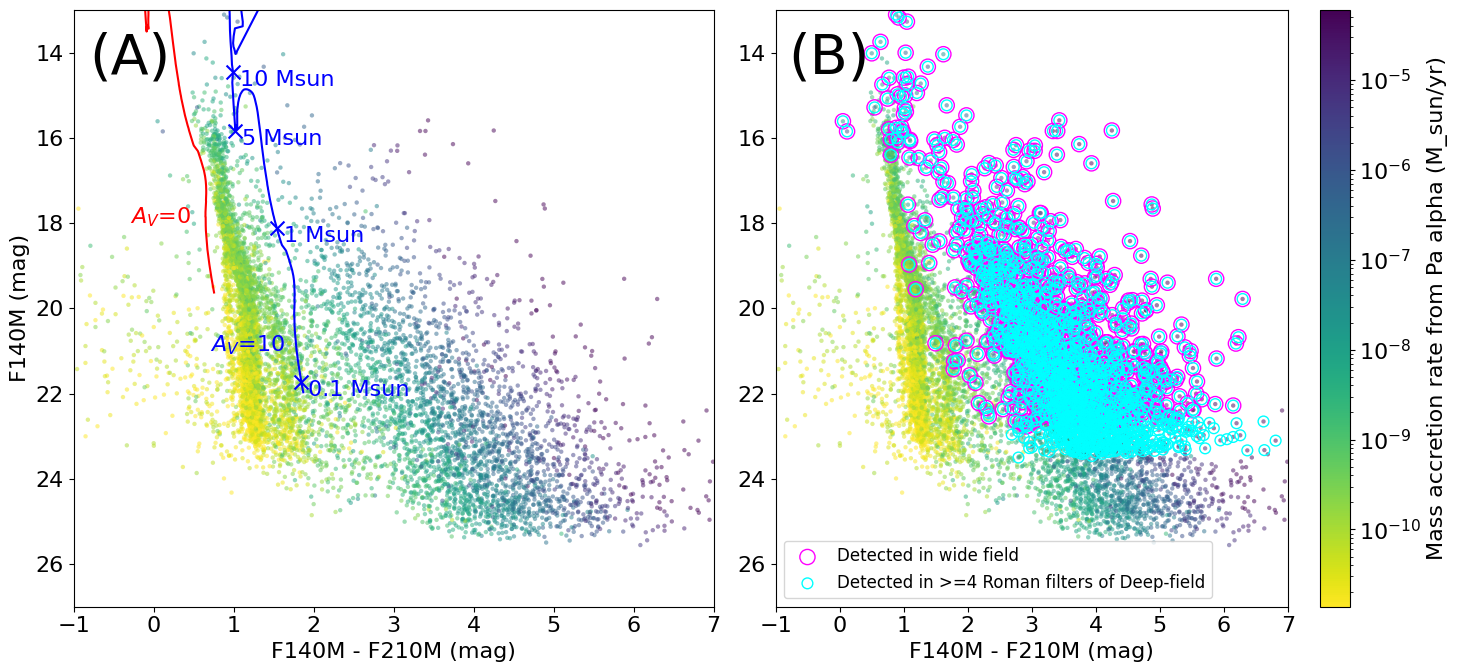

In [137]:
import numpy as np
import astropy.units as u
from astropy.constants import h, c, k_B
from astroquery.svo_fps import SvoFps
from dust_extinction.parameter_averages import CCM89
def planck_B_lambda(wav, T):
    """
    wav: wavelength Quantity [length]
    T: temperature Quantity [K]
    returns B_lambda in W / (m^2 sr m)
    """
    wav_m = wav.to(u.m)
    x = (h * c / (wav_m * k_B * T)).decompose().value
    # add /u.sr explicitly so astropy tracks steradian correctly
    B = ((2 * h * c**2) / wav_m**5) / np.expm1(x) / u.sr
    return B.to(u.W / (u.m**2 * u.sr * u.m))

def f140m_vega_mag_blackbody(
    T=30000*u.K,
    Rstar=10*u.R_sun,
    d=5.4*u.kpc,
    Av=20.0,
    Rv=3.1
):
    flist = SvoFps.get_filter_list('JWST')
    flist.add_index('filterID')
    zp_vega = u.Quantity(flist.loc['JWST/NIRCam.F140M']['ZeroPoint'], u.Jy)

    ttab = SvoFps.get_transmission_data('JWST/NIRCam.F140M')
    lam_col = ttab['Wavelength']
    lam = (lam_col.quantity if hasattr(lam_col, "quantity") else lam_col * u.AA).to(u.AA)
    Tlam = np.array(ttab['Transmission'])

    B_lam = planck_B_lambda(lam, T)

    # multiply by pi*sr to convert radiance -> surface flux
    F_lam = (np.pi * u.sr * B_lam * (Rstar/d)**2).to(u.W / (u.m**2 * u.m))

    ext = CCM89(Rv=Rv)
    A_lam = Av * ext((1/lam.to(u.um)).value) * u.mag
    F_lam_ext = F_lam * 10**(-0.4 * A_lam.value)

    F_nu_ext = (F_lam_ext * lam.to(u.m)**2 / c).to(u.Jy)

    num = np.trapz(F_nu_ext.value * Tlam, x=lam.value)
    den = np.trapz(Tlam, x=lam.value)
    fnu_band = (num / den) * u.Jy

    m_vega = -2.5 * np.log10((fnu_band / zp_vega).decompose().value)
    return fnu_band, m_vega, zp_vega
fnu, mveg_av20, zp = f140m_vega_mag_blackbody()
print(fnu, mveg_av20, zp)
fnu, mveg_av30, zp = f140m_vega_mag_blackbody(Av=30.0)
print(fnu, mveg_av30, zp)

# get the color F140M-F210M where it has mveg_av20 and mveg_av30

def get_color_from_av(av_value, mag, ext=RL85_MWGC(), color1=('f140m', 'f162m'), mag1=('f140m',), isochrone_line_params=(color_slope, color_intercept)):
    m_iso, b_iso = isochrone_line_params
    w_color1_1 = int(color1[0][1:-1])/100*u.um
    w_color1_2 = int(color1[1][1:-1])/100*u.um
    w_mag1 = int(mag1[0][1:-1])/100 *u.um
    e_color1_1 = ext(1/w_color1_1)
    e_color1_2 = ext(1/w_color1_2)
    e_mag1 = ext(1/w_mag1)
    m_ext = e_mag1 / (e_color1_1 - e_color1_2)

    # Strip units if present
    mag_val = mag.value if hasattr(mag, 'value') else float(mag)

    # Reddened point: start from unextincted mag and shift along extinction vector by av_value
    # mag_unreddened = mag_val - av_value * e_mag1
    # color_unreddened = (mag_unreddened - b_iso) / m_iso
    # color_reddened = color_unreddened + av_value * (e_color1_1 - e_color1_2)
    mag_unreddened = mag_val - av_value * e_mag1
    color_unreddened = (mag_unreddened - b_iso) / m_iso
    color_reddened = color_unreddened + av_value * (e_color1_1 - e_color1_2)
    return color_reddened
color_av20 = get_color_from_av(20, mveg_av20, ext=ext, color1=('f140m', 'f210m'), mag1=('f140m',), isochrone_line_params=(color_slope, color_intercept))
color_av30 = get_color_from_av(30, mveg_av30, ext=ext, color1=('f140m', 'f210m'), mag1=('f140m',), isochrone_line_params=(color_slope, color_intercept))
print(color_av20, color_av30)




# plot color magnitude diagram F140M-F210M vs F140M with points colored by mass accretion rate from Pa alpha
from matplotlib.colors import LogNorm
fig = plt.figure(figsize=(15, 7))
ax = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
cmap = plt.get_cmap('viridis_r')
# color coding in log scale
norm = LogNorm(vmin=np.nanpercentile(macc_from_paa.value, 10), vmax=np.nanpercentile(macc_from_paa.value, 99))
color = (filters['f140m'][0] - filters['f210m'][0])
magnitude = filters['f140m'][0]
ax.scatter(color.value, magnitude.value, s=10, c=macc_from_paa.value, cmap=cmap, alpha=0.5, edgecolor='none', norm=norm)
ax2.scatter(color.value, magnitude.value, s=10, c=macc_from_paa.value, cmap=cmap, alpha=0.5, edgecolor='none', norm=norm)
ax2.scatter(color.value[idx_detected_wf], magnitude.value[idx_detected_wf], s=120, facecolors='none', edgecolors='magenta', label='Detected in wide field')
ax2.scatter(color.value[idx_detected_deep_ge_4], magnitude.value[idx_detected_deep_ge_4], s=60, facecolors='none', edgecolors='cyan', label='Detected in >=4 Roman filters of Deep-field')
print('len(idx_saturated_wf):', len(idx_saturated_wf), 'len(idx_detected_deep_ge_4):', len(idx_detected_deep_ge_4))
ax.set_xlabel('F140M - F210M (mag)')
ax.set_ylabel('F140M (mag)')
ax2.set_xlabel('F140M - F210M (mag)')
#ax.set_title('CMD colored by mass accretion rate from Pa alpha')
ax.set_xlim(-1,7)
ax.set_ylim(27, 13)
ax2.set_xlim(-1,7)
ax2.set_ylim(27, 13)
# add colorbar for mass accretion ratefrom Pa alpha
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax2)
cbar.set_label('Mass accretion rate from Pa alpha (M_sun/yr)')
# use fill_between to show the area above the line connecting the two points as the area where a B3V star would lie, assuming A_V between 20 and 30
#plot the line connecting the two points (color_av20, mveg_av20) and (color_av30, mveg_av30) but extrapolate it to x=-1 and x=7
av20_x = color_av20
av20_y = mveg_av20
av30_x = color_av30
av30_y = mveg_av30
slope = (av30_y - av20_y) / (av30_x - av20_x)
intercept = av20_y - slope * av20_x
x_vals = np.array([-1, 7]) 
y_vals = slope * x_vals + intercept
#ax.plot(x_vals, y_vals, color='orange', linestyle='--')
#ax.fill_between(x_vals, y_vals, y_vals-20, color='orange', alpha=0.1)

age_idx = logage_av0 == 6

ax.plot(F140Mmag_av0[age_idx] - F210Mmag_av0[age_idx], F140Mmag_av0[age_idx], color='r')

    #ax.annotate(f'{mass} Msun', (F140Mmag_av0[age_idx][idx_mass] - F162Mmag_av0[age_idx][idx_mass], F140Mmag_av0[age_idx][idx_mass]), textcoords="offset points", xytext=(5,-10), ha='left', color='r')
age_idx = logage_av10 == 6

ax.plot(F140Mmag_av10[age_idx] - F210Mmag_av10[age_idx], F140Mmag_av10[age_idx], color='b')
for mass in [0.1, 1, 5, 10]:
    idx_mass = np.argmin(np.abs(mass_av10[age_idx]-mass))
    ax.scatter(F140Mmag_av10[age_idx][idx_mass] - F210Mmag_av10[age_idx][idx_mass], F140Mmag_av10[age_idx][idx_mass], color='b', marker='x', s=100)
    ax.annotate(f'{mass} Msun', (F140Mmag_av10[age_idx][idx_mass] - F210Mmag_av10[age_idx][idx_mass], F140Mmag_av10[age_idx][idx_mass]), textcoords="offset points", xytext=(5,-10), ha='left', color='b')

#ax.text(3,15, 'wind-dominated regime\n(B0 or earlier)')
ax.text(-0.3, 18, r'$A_V$=0',color='r')
ax.text(0.7, 21, r'$A_V$=10', color='b')
ax2.legend(loc='lower left', fontsize=12)
ax2.set_xticks(np.arange(-1, 8, 1))
plt.tight_layout()
ax.text(-0.8,14.5, '(A)', fontsize=40)
ax2.text(-0.8,14.5, '(B)', fontsize=40)
plt.savefig('cmd_for_roman.png', dpi=300)

# get the number of sources with A_v>10
num_av_gt_10 = np.sum(av_values > 10)
print(f'Number of sources with A_V > 10: {num_av_gt_10}')